## **Libraries**

In [81]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## **Dataset Importing & Cleaning**

In [82]:
df= pd.read_csv(r"Synthetic.csv")
df.head()

,Unnamed: 0,X,Y
0,0,37.454012,126.746701
1,1,95.071431,293.927975
2,2,73.199394,225.441700
3,3,59.865848,183.586508
4,4,15.601864,39.020372


In [83]:
df=df.iloc[:,1:3]

In [84]:
df.head()

,X,Y
0,37.454012,126.746701
1,95.071431,293.927975
2,73.199394,225.441700
3,59.865848,183.586508
4,15.601864,39.020372


## **Extracting Features and labels**

In [85]:
X=df.iloc[:,0].values
Y=df.iloc[:,1].values

In [86]:
X.shape,Y.shape

((50,), (50,))

In [87]:
df.describe()

,X,Y
count,50.000000,50.000000
mean,44.592390,140.747718
std,28.888320,86.506304
min,2.058449,14.483926
25%,18.376700,71.464987
50%,43.604876,133.321421
75%,64.985494,198.773689
max,96.990985,307.312098


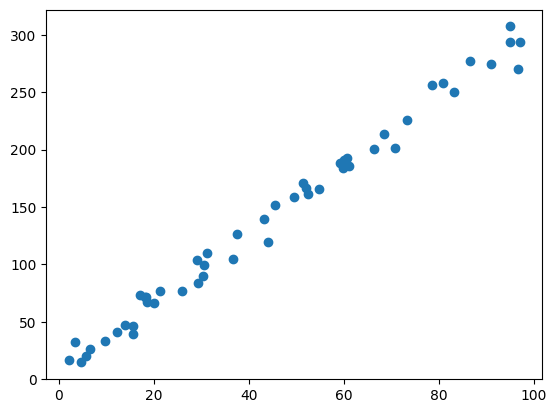

In [88]:
plt.scatter(x=X,y=Y)


## **Gradient Descent**

In [107]:
class GradientDescent:
    def __init__(self,x,y,lr=0.0001,epochs=10000,tolerance=0.001):
        self.x=x
        self.y=y
        self.lr=lr
        self.epochs=epochs
        self.tolerance=tolerance

    def dim(self):
        if self.x.ndim == 1:
            self.x=self.x.reshape(-1,1)

        self.y=self.y.reshape(-1,1)
        self.m,self.features=self.x.shape
        shape={'m': self.m,
               'features': self.features}
        return shape


    def standardize(self):
        self.x = (self.x - np.mean(self.x ,axis=0))/np.std(self.x,axis=0)
        return self.x
    
    def initialize_parameters(self):
        self.w = np.random.randn(self.features,1)
        self.b = np.zeros((1,1))
        parameters={"w":self.w,
                    "b": self.b}
        return parameters



    def forward_pass(self):
        self.y_hat = np.dot(self.x,self.w) + self.b 
        return self.y_hat

    def compute_cost(self):
        cost = 1/2 * np.mean((self.y_hat - self.y)**2) 
        return cost




    def BGD(self):
        epoch = 0
        prev_loss=float("inf")
        losses=[]
        while epoch < self.epochs :

            self.y_hat = self.forward_pass()
            loss = self.compute_cost()

            dw= 1/self.m * np.dot(self.x.T,(self.y_hat - self.y))
            db= 1/self.m * np.sum(self.y_hat - self.y)

            self.w= self.w - self.lr * dw
            self.b= self.b - self.lr * db

            losses.append(loss)

            if abs(prev_loss-loss) < self.tolerance:
                break
            prev_loss = loss
            epoch += 1

        self.plot_loss(losses)
        bgd_param = {"w":self.w,
                     "b": self.b,
                     "loss": loss}
        return bgd_param
            

    def SGD(self):
        epoch = 0
        prev_loss = float("inf")
        losses=[]
        while epoch < self.epochs:
            indices = np.random.permutation(self.m)
            for i in indices:
                x_i = self.x[i:i+1]
                y_i = self.y[i:i+1]

                y_hat_i = np.dot(x_i,self.w) + self.b

                error = y_hat_i - y_i

                dw = np.dot(x_i.T,error)
                db = error
                
                self.w= self.w - self.lr * dw
                self.b= self.b - self.lr * db

            self.y_hat = self.forward_pass()
            loss= self.compute_cost()
            losses.append(loss)
            

            if abs(prev_loss-loss)< self.tolerance:
                break
            prev_loss= loss
            epoch += 1
        self.plot_loss(losses)

        sgd_parameters ={"w": self.w,
                         "b": self.b,
                         "loss":loss} 

        return sgd_parameters


        
    def MBGD(self):
        pass

    def fit(self,method ="BGD"):
        self.dim()
        self.standardize()
        self.initialize_parameters()
        if method == "BGD":
            return self.BGD()
        elif method =="SGD":
            return self.SGD()
        elif method =="MBGD":
            return self.MBGD()


    def plot_loss(self,losses,method="BGD"):
        epochs = range(1,len(losses)+1)

        plt.plot(epochs,losses)
        plt.xlabel("Number of epochs")
        plt.ylabel("Total Loss")
        if method == "BGD":
            plt.title("Batch Gradient Descent Loss Graph")
        elif method == "SGD":
            plt.title("Stochastic Gradient Descent Loss Graph")
        elif method == "MBGD":
            plt.title("MiniBatch Gradient Descent Loss Graph")
        
        plt.show()

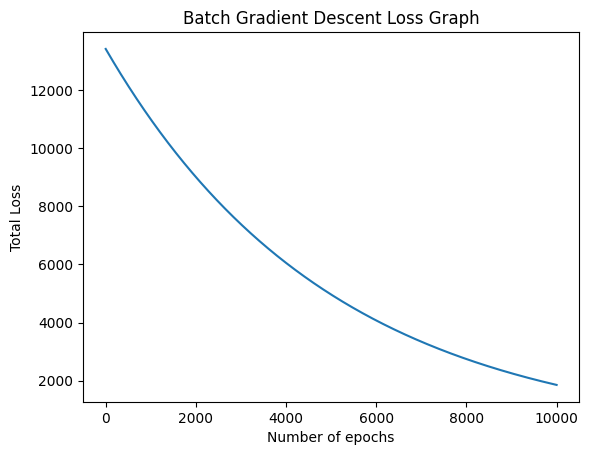

{'w': array([[54.50333252]]),
 'b': array([[88.97211547]]),
 'loss': np.float64(1851.6332251606862)}

In [111]:
model1=GradientDescent(X,Y,epochs=10000)
model1.fit(method="BGD")

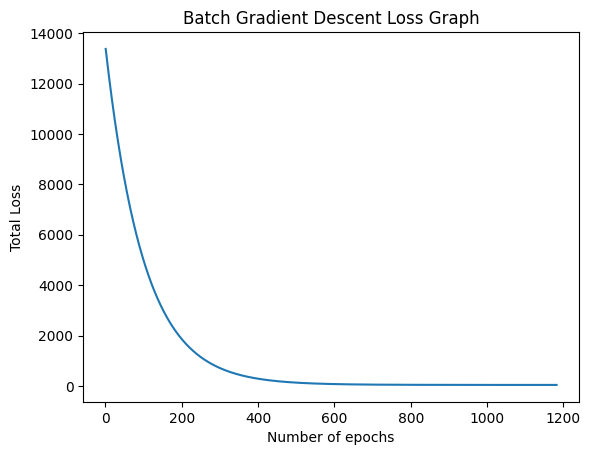

{'w': array([[84.92629458]]),
 'b': array([[140.36618677]]),
 'loss': np.float64(41.25248377059804)}

In [112]:
model2=GradientDescent(X,Y)
model2.fit(method="SGD")